# Objective

Analyze stock market data to understand price movements, trading activity, relationships between variables, and key statistical patterns.

# Dataset

- 497,461 observations
- 7 columns
- Features:
  - symbol
  - date
  - open
  - high
  - low
  - close
  - volume

# Key Findings

- Apple (AAPL) showed a strong upward trend in closing prices over the observed period.
- BAC recorded the highest total trading volume among the analyzed stocks.
- Open, High, Low, and Close prices are highly correlated.
- Trading volume has a weak correlation with stock prices.
- The dataset contains only a small number of missing values.
- Closing prices are right-skewed, with most stocks concentrated in lower price ranges.

# Conclusion

The stock market dataset was successfully analyzed using exploratory data analysis techniques. Price-related variables (Open, High, Low, and Close) showed very strong positive correlations, indicating they move together closely. Apple (AAPL) demonstrated a strong upward trend in closing prices, while BAC recorded the highest trading volume. The dataset contained very few missing values, and the distribution of closing prices was right-skewed. Overall, the analysis provides valuable insights into stock price behavior and trading activity.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [6]:
import os

os.getcwd()

'C:\\Users\\OMEN LAPTOP 15'

In [7]:
os.listdir()

['-1.14-windows.xml',
 '.blip-device-dedupe-id',
 '.cache',
 '.codex',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.skiko',
 'AppData',
 'Application Data',
 'battery-report.html',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Heaven',
 'inst.ini',
 'IntelGraphicsProfiles',
 'Iris_EDA_Project.ipynb',
 'Links',
 'Local Settings',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{6f212a49-ec98-11ef-81d7-af459868b8fd}.TM.blf',
 'NTUSER.DAT{6f212a49-ec98-11ef-81d7-af459868b8fd}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{6f212a49-ec98-11ef-81d7-af459868b8fd}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'nuuid.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Stock_Prices_EDA_Project',
 'Templates',
 'useruid.ini',
 'vmlogs']

In [8]:
import pandas as pd

df = pd.read_csv("Downloads/2) Stock Prices Data Set.csv")

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [9]:
print("shape:",df.shape)
df.info()

shape: (497472, 7)
<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [10]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [11]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [13]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [16]:
top_volume = df.groupby("symbol")["volume"].sum().sort_values(ascending=False).head(10)

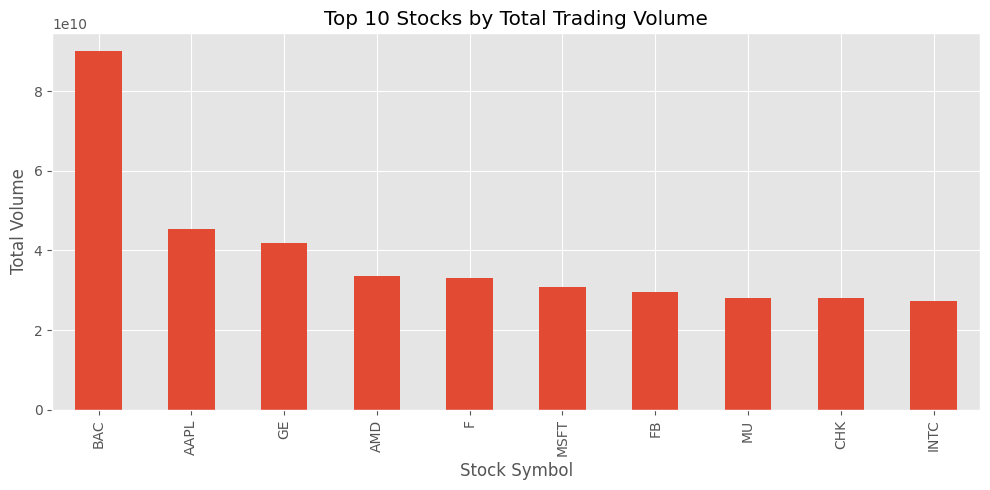

In [17]:
import matplotlib.pyplot as plt

top_volume.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Stocks by Total Trading Volume')
plt.xlabel('Stock Symbol')
plt.ylabel('Total Volume')
plt.tight_layout()

plt.show()

In [18]:
df['date'] = pd.to_datetime(df['date'])

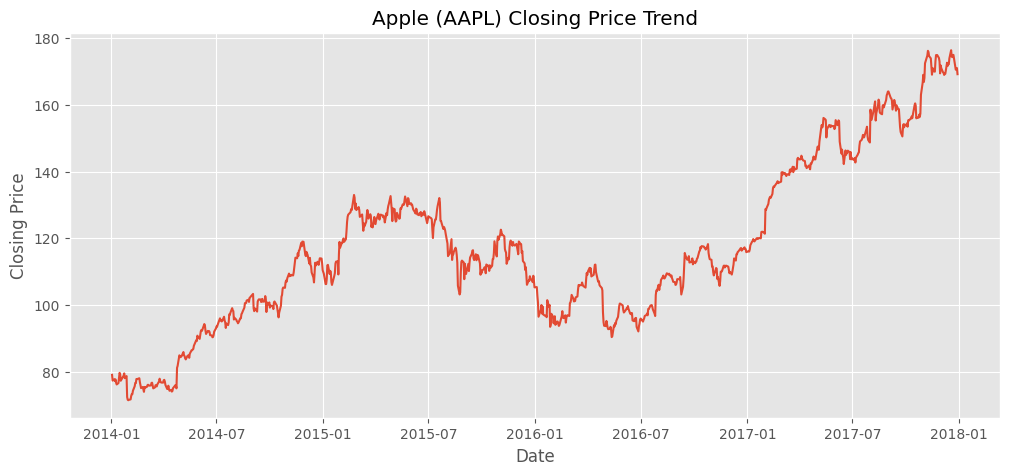

In [19]:
apple = df[df['symbol'] == 'AAPL']

apple = apple.sort_values('date')

plt.figure(figsize=(12,5))
plt.plot(apple['date'], apple['close'])

plt.title('Apple (AAPL) Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [20]:
df[['open','high','low','close','volume']].corr()

,open,high,low,close,volume
open,1.000000,0.999941,0.999928,0.999876,-0.148724
high,0.999941,1.000000,0.999905,0.999938,-0.148344
low,0.999928,0.999905,1.000000,0.999941,-0.149284
close,0.999876,0.999938,0.999941,1.000000,-0.148839
volume,-0.148724,-0.148344,-0.149284,-0.148839,1.000000


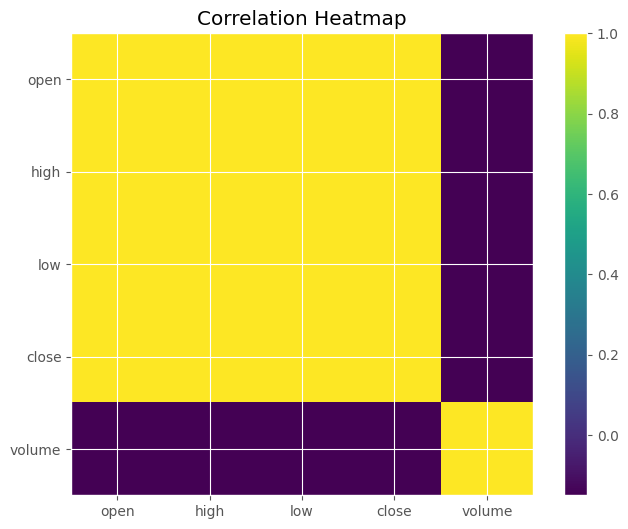

In [21]:
import matplotlib.pyplot as plt

corr = df[['open','high','low','close','volume']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')
plt.show()

In [22]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

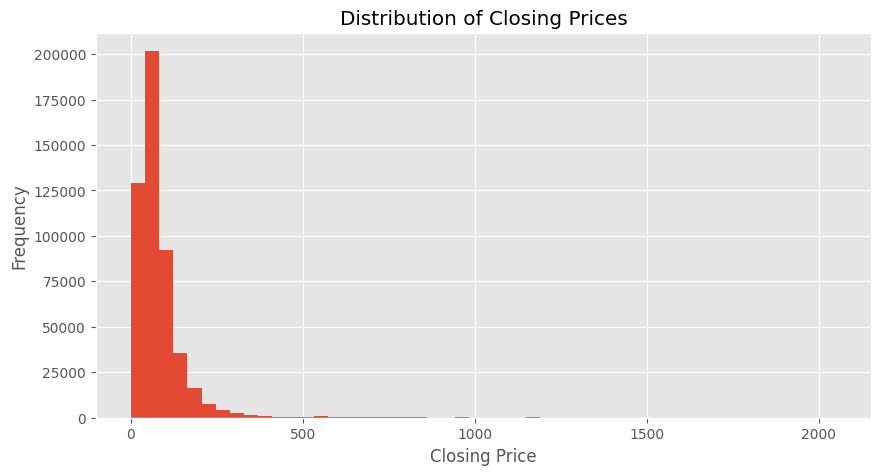

In [23]:
import matplotlib.pyplot as plt

df['close'].hist(bins=50, figsize=(10,5))
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

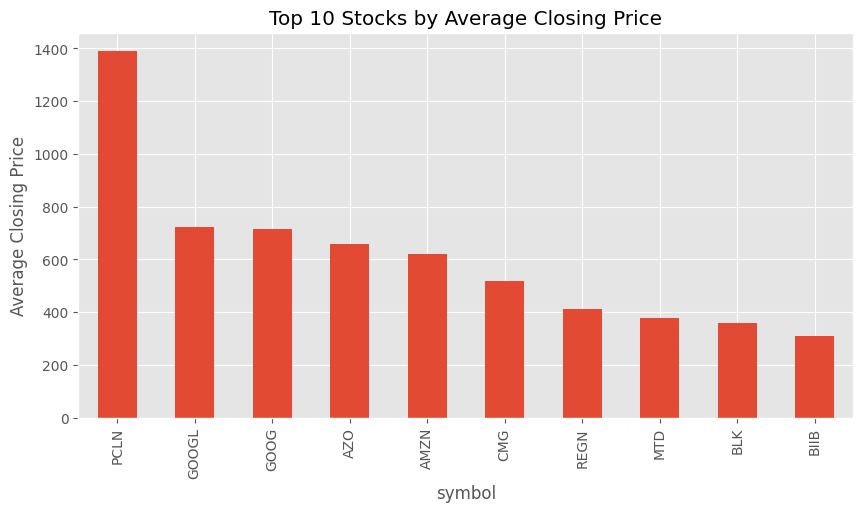

In [24]:
top_close = df.groupby('symbol')['close'].mean().sort_values(ascending=False).head(10)

top_close.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Stocks by Average Closing Price')
plt.ylabel('Average Closing Price')
plt.show()